# Task 1 — Data Loading & Exploration

In [40]:
#Load the CSV file using Pandas
import pandas as pd
housing_data = pd.read_csv('Housing.csv')
print(housing_data.head(10))         # printing the first 10 rows

      price   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000   7420         4          2        3      yes        no       no   
1  12250000   8960         4          4        4      yes        no       no   
2  12250000   9960         3          2        2      yes        no      yes   
3  12215000   7500         4          2        2      yes        no      yes   
4  11410000   7420         4          1        2      yes       yes      yes   
5  10850000   7500         3          3        1      yes        no      yes   
6  10150000   8580         4          3        4      yes        no       no   
7  10150000  16200         5          3        2      yes        no       no   
8   9870000   8100         4          1        2      yes       yes      yes   
9   9800000   5750         3          2        4      yes       yes       no   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      

In [41]:
# To check how many rows and columns are there
print(housing_data.shape)

(545, 13)


In [42]:
# Identify Target and Features
# Target variable
target = "price"

# Feature variables
features = housing_data.columns.drop(target)

print("Target Column:", target)
print("Feature Columns:", list(features))

Target Column: price
Feature Columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [43]:
# Checking for missing values in each column
# check dataset info
housing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [44]:
#Check missing values in each column
housing_data.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

# Task 2 — Data Cleaning

In [45]:
# Handle missing values
# If missing values exist, fill or drop
housing_data = housing_data.dropna()   # Since this dataset doesn't consist of any null values use dropna
housing_data

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [46]:
#To Remove Duplicate Rows(if existed)
# Check duplicates
housing_data.duplicated().sum()      #Their are no duplicate rows so we don't need to use the code to remove duplicates

np.int64(0)

In [47]:
# Convert yes/no columns
yes_no_cols = ['mainroad', 'guestroom', 'basement', 
               'hotwaterheating', 'airconditioning', 'prefarea']

for col in yes_no_cols:
    if housing_data[col].dtype == 'object':
        housing_data[col] = housing_data[col].map({'yes': 1, 'no': 0})

# Apply one-hot encoding
if 'furnishingstatus' in housing_data.columns:
    housing_data = pd.get_dummies(housing_data, columns=['furnishingstatus'], drop_first=True)

# Final check
housing_data

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,False,True
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,True,False
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,False,True
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,False,False


# Task 3 — Model Building

In [48]:
# Split the data into training and test sets (80/20)
from sklearn.model_selection import train_test_split

# Features (X) and Target (y)
X = housing_data.drop('price', axis=1)
y = housing_data['price']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (436, 13)
Testing size: (109, 13)


In [49]:
# Evaluate it using MAE, RMSE, and R² Score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance:")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

Linear Regression Performance:
MAE: 970043.403920164
RMSE: 1324506.9600914388
R2 Score: 0.6529242642153184


In [50]:
from sklearn.linear_model import LinearRegression

# Create model
lr_model = LinearRegression()

# Train model
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)          # Train a Linear Regression model to predict house price
from sklearn.linear_model import LinearRegression


In [51]:
print(X_train.dtypes)

area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
mainroad                           int64
guestroom                          int64
basement                           int64
hotwaterheating                    int64
airconditioning                    int64
parking                            int64
prefarea                           int64
furnishingstatus_semi-furnished     bool
furnishingstatus_unfurnished        bool
dtype: object


In [52]:
# Train Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

# Create model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

In [53]:
# Evaluate Random Forest
# Metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRandom Forest Performance:")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)


Random Forest Performance:
MAE: 1022560.0527522935
RMSE: 1401496.8425384816
R2 Score: 0.6114024924156645


In [54]:
# Compare Models
print("\nModel Comparison:")

print(f"Linear Regression R2: {r2_lr}")
print(f"Random Forest R2: {r2_rf}")


Model Comparison:
Linear Regression R2: 0.6529242642153184
Random Forest R2: 0.6114024924156645


# Task 4 — Visualization 

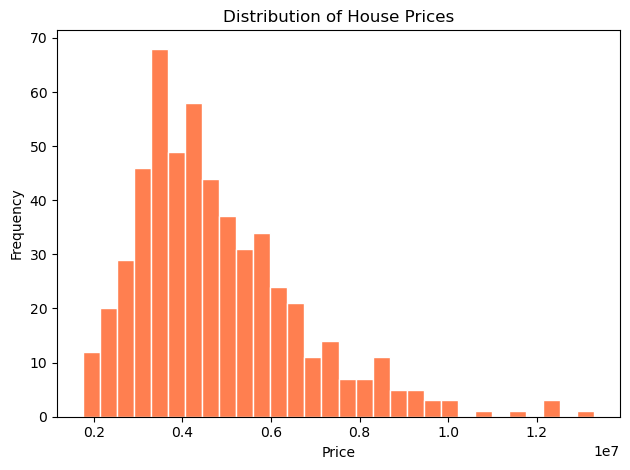

In [68]:
# Chart 1: Histogram showing the distribution of house prices
import os
import matplotlib.pyplot as plt

# Create folder
os.makedirs("charts", exist_ok=True)

plt.figure()
plt.hist(housing_data['price'], bins=30, color='#FF7F50', edgecolor='white')

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

# Show plot
plt.tight_layout()
plt.savefig("charts/histogram.png")
plt.show()

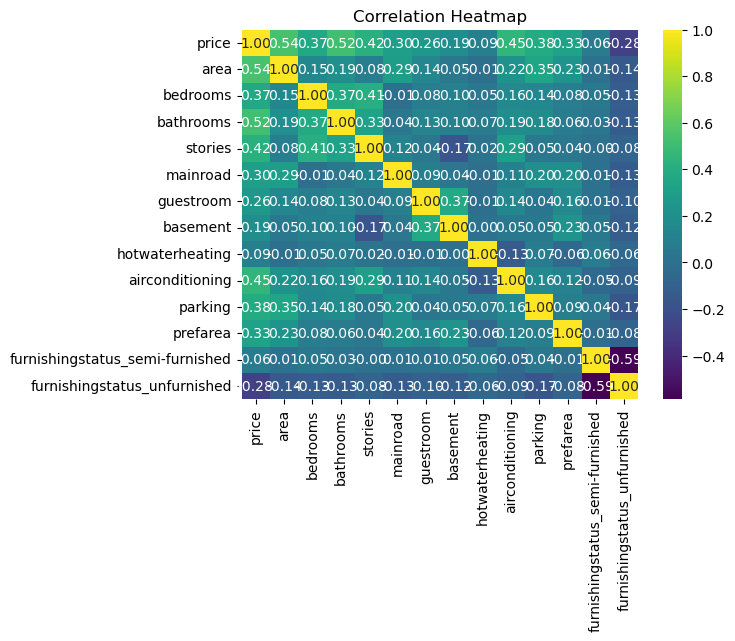

In [69]:
# Chart 2: Correlation heatmap showing which features relate most strongly to price
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.heatmap(housing_data.corr(), annot=True, fmt=".2f", cmap='viridis')
plt.title("Correlation Heatmap")

plt.savefig("charts/heatmap.png")
plt.show()

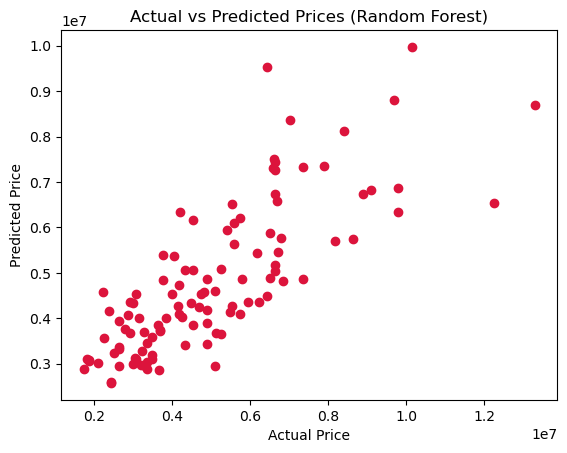

In [70]:
# Chart 3: Scatter Plot (Actual vs Predicted Price)
plt.figure()
plt.scatter(y_test, y_pred_rf, color='crimson')
plt.title("Actual vs Predicted Prices (Random Forest)")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.savefig("charts/scatter.png")

plt.show()

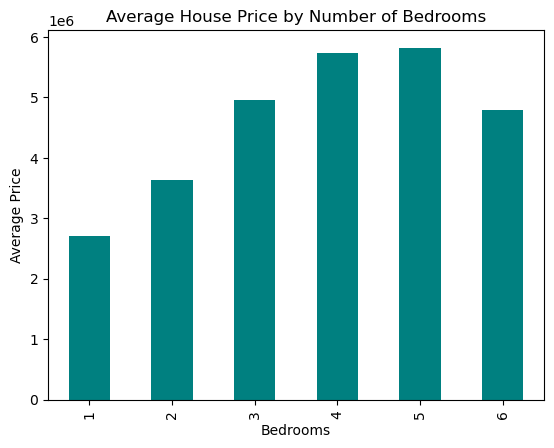

In [71]:
# Chart 4: Average Price by Number of Bedrooms (Bar Chart)
import matplotlib.pyplot as plt

# Group data
avg_price_bedrooms = housing_data.groupby('bedrooms')['price'].mean()

# Plot
plt.figure()
avg_price_bedrooms.plot(kind='bar', color='teal')

plt.title("Average House Price by Number of Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Average Price")

plt.savefig("charts/bar.png")

plt.show()

# Task 5 — Insights & Summary

In this project, features such as area, number of bathrooms, and number of bedrooms were found to have the strongest influence on house prices, as they showed higher correlation values. The models performed reasonably well, with the Random Forest Regressor providing better accuracy compared to Linear Regression, indicating its ability to capture complex relationships. One surprising observation was that some features like hot water heating had very little impact on price. Additionally, furnishing status had a noticeable effect on pricing. Based on these findings, a real estate business should focus on properties with larger area and better amenities, as these significantly increase property value and attract higher prices.
